In [28]:
import requests
import difflib
import csv
import re
from collections import defaultdict
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

#parameters

URL = "https://en.wikipedia.org/w/api.php"

HEADERS = {
    "User-Agent": "WikiEditStudy/1.0 (student project)"
}

PARAMS = {
    "action": "query",
    "format": "json",
    "prop": "revisions",
    "titles": "Legal status of transgender people",
    "rvprop": "content",
    "rvslots": "main",
    "rvstart": "2023-12-31T23:59:59Z",
    "rvend": "2022-01-01T00:00:00Z",
    "rvlimit": "max",
    "rvdir": "older"
}


In [29]:
# tokenizer

STOP_WORDS = list(ENGLISH_STOP_WORDS) + ["date", "archive","url","web","access","https","ref","org","website","www","http"]
def tokenize(text):
    """Lowercase and extract alphabetic words."""
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    return [w for w in words if w not in STOP_WORDS]

In [30]:
#edits finder

def get_revisions():
    revisions = []
    cont = {}

    while True:
        params = PARAMS.copy()
        params.update(cont)

        r = requests.get(URL, params=params, headers=HEADERS)
        data = r.json()

        pages = data["query"]["pages"]
        page = next(iter(pages.values()))

        for rev in page["revisions"]:
            slot = rev["slots"]["main"]
            text = slot.get("*", slot.get("content", ""))
            if text:
                revisions.append(text)

        if "continue" in data:
            cont = data["continue"]
        else:
            break

    return revisions

In [31]:
def main():
    revisions = get_revisions()

    added_counts = defaultdict(int)
    removed_counts = defaultdict(int)

    for i in range(len(revisions) - 1):
        old_words = tokenize(revisions[i])
        new_words = tokenize(revisions[i + 1])

        diff = difflib.ndiff(old_words, new_words)

        for d in diff:
            word = d[2:]
            if d.startswith("+ "):
                added_counts[word] += 1
            elif d.startswith("- "):
                removed_counts[word] += 1

    # Merge counts and compute net
    all_words = set(list(added_counts.keys()) + list(removed_counts.keys()))
    results = []

    for word in all_words:
        added = added_counts.get(word, 0)
        removed = removed_counts.get(word, 0)
        net = added - removed
        results.append({
            "word": word,
            "times_added": added,
            "times_removed": removed,
            "net_change": net
        })

    # Sort by times_added descending
    results.sort(key=lambda x: x["times_added"], reverse=True)

    # Write CSV
    with open("wiki_word_summary.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["word", "times_added", "times_removed", "net_change"])
        writer.writeheader()
        writer.writerows(results)

    print("Saved wiki_word_summary.csv")


if __name__ == "__main__":
    main()


Saved wiki_word_summary.csv


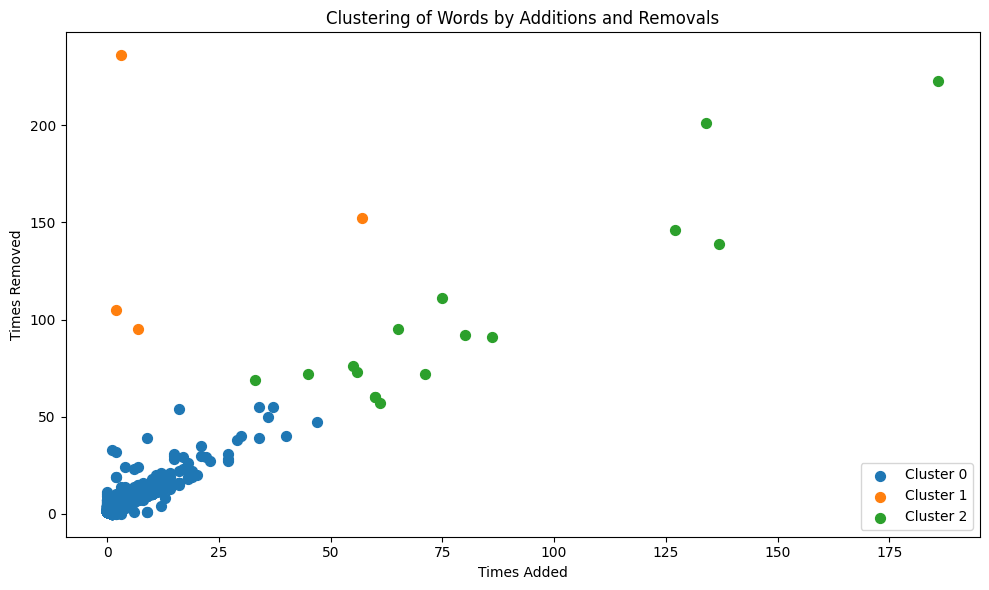

Cluster 0 top words (by net change): ['archived', 'copy', 'newspaper', 'gaystarnews', 'author', 'periodical', 'continue', 'finnish', 'gs', 'victory']
Cluster 1 top words (by net change): ['yes', 'legal', 'prohibited', 'flag']
Cluster 2 top words (by net change): ['transsexual', 'went', 'mow', 'august', 'man', 'live', 'people', 'com', 'status', 'identity']


In [35]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# -----------------------------
# Load the CSV
# -----------------------------
df = pd.read_csv("wiki_word_summary.csv")  # columns: word, times_added, times_removed, net_change

# -----------------------------
# Feature matrix
# -----------------------------
# Use added, removed, and net as features
X = df[["times_added", "times_removed", "net_change"]].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Dimensionality reduction for visualization
# -----------------------------
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_scaled)

# -----------------------------
# Unsupervised clustering
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_reduced)

df["cluster"] = clusters

# -----------------------------
# Plot clusters
# -----------------------------
plt.figure(figsize=(10,6))
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["times_added"], subset["times_removed"], label=f"Cluster {c}", s=50)

plt.xlabel("Times Added")
plt.ylabel("Times Removed")
plt.title("Clustering of Words by Additions and Removals")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: Inspect top words per cluster
# -----------------------------
for c in sorted(df["cluster"].unique()):
    top_words = df[df["cluster"] == c].sort_values("net_change", ascending=False).head(10)["word"].tolist()
    print(f"Cluster {c} top words (by net change): {top_words}")

In [36]:
df = pd.read_csv("wiki_word_summary.csv")  # columns: word, times_added, times_removed, net_change

# -----------------------------
# Feature matrix
# -----------------------------
X = df[["times_added", "times_removed", "net_change"]].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Apply KMeans clustering
# -----------------------------
k = 3  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# -----------------------------
# Sort by cluster
# -----------------------------
df_sorted = df.sort_values("cluster").reset_index(drop=True)

# -----------------------------
# Export to CSV
# -----------------------------
df_sorted.to_csv("wiki_word_clusters_sorted.csv", index=False)

print("Saved wiki_word_clusters_sorted.csv with words grouped by cluster.")

Saved wiki_word_clusters_sorted.csv with words grouped by cluster.
